## Milestone 1

Dataset: https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import shap
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

/Users/dylan/Documents/CSE 475 - Foundations of Machine Learning/cse475-final/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This is the classic marketing bank dataset uploaded originally in the UCI Machine Learning Repository. The dataset gives you information about a marketing campaign of a financial institution in which you will have to analyze in order to find ways to look for future strategies in order to improve future marketing campaigns for the bank.

In [2]:
df = pd.read_csv('bank.csv')

# Looking at the unique jobs
drop_cols = [col for col in df.columns if col != 'job']
jobs = df.drop(columns=drop_cols)
jobs = jobs.drop_duplicates()

df.head(10)
#jobs


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


In [3]:
#Checking for null values
print(df.isnull().sum())
print(df['poutcome'].value_counts())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


Text(0.5, 1.0, 'Age Distribution')

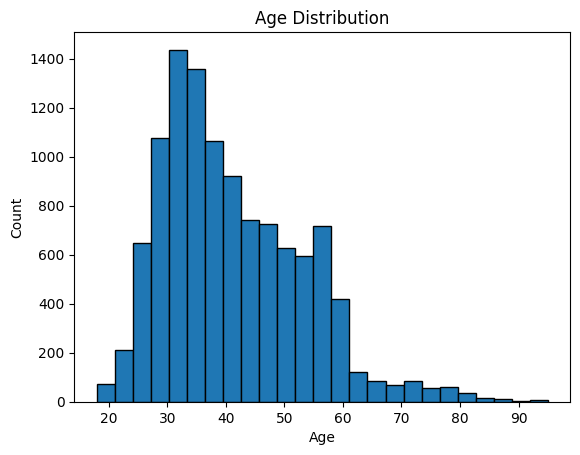

In [4]:
# Age distribution of the people that took part in the marketing campaign

plt.hist(df['age'], edgecolor='black', bins=25)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')

Text(0.5, 1.0, 'Age vs Balance')

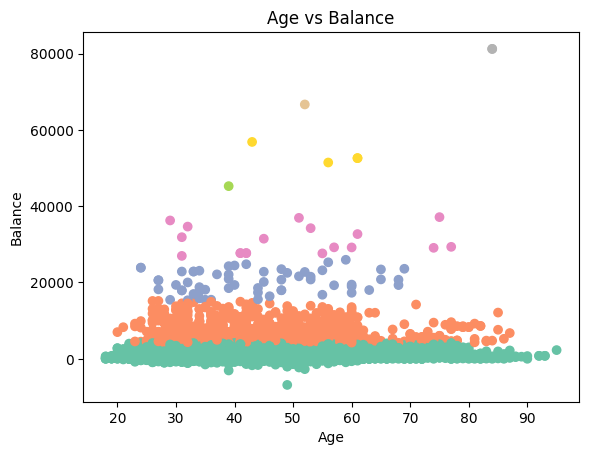

In [5]:
# Age vs balance plot
plt.scatter(df['age'], df['balance'], c = df['balance'], cmap='Set2')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Age vs Balance')

The data in general was pretty much cleaned before except for the outcome column where most of the values are unknown but there are enough successes, failures, and others to this column be relevant. Though I did find that there are some negative values for balance of certain jobs. Like management, entrepeneur and self-employed positions but since this does not create outliers that drastically affect the data, I am going to leave them in.

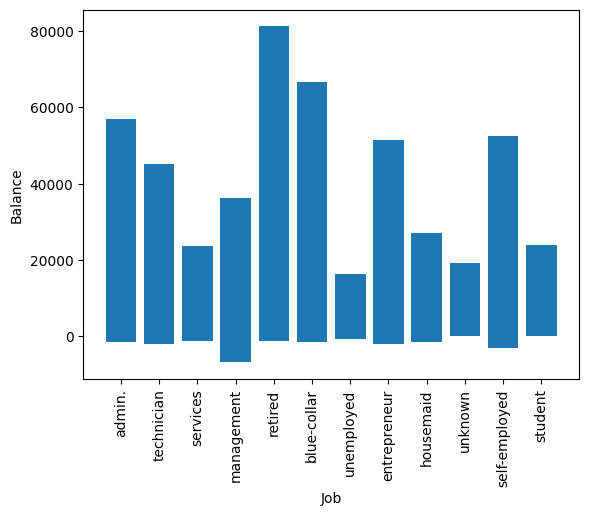

In [6]:
#Job to balance graph
plt.bar(df['job'], df['balance'])
plt.xlabel('Job')
plt.ylabel('Balance')
plt.xticks(rotation=90)
plt.show()

In [7]:
#One hot encode categorical values as int
df = pd.get_dummies(df, columns=['job', 'marital', 'housing', 'loan', 'education', 'contact', 'month', 'poutcome', 'deposit', 'contact', 'default'])
df

,age,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,poutcome_other,poutcome_success,poutcome_unknown,deposit_no,deposit_yes,contact_cellular,contact_telephone,contact_unknown,default_no,default_yes
0,59,2343,5,1042,1,-1,0,True,False,False,...,False,False,True,False,True,False,False,True,True,False
1,56,45,5,1467,1,-1,0,True,False,False,...,False,False,True,False,True,False,False,True,True,False
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,True,False,True,False,False,True,True,False
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,True,False,True,False,False,True,True,False
4,54,184,5,673,2,-1,0,True,False,False,...,False,False,True,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,False,True,False,...,False,False,True,True,False,True,False,False,True,False
11158,39,733,16,83,4,-1,0,False,False,False,...,False,False,True,True,False,False,False,True,True,False
11159,32,29,19,156,2,-1,0,False,False,False,...,False,False,True,True,False,True,False,False,True,False
11160,43,0,8,9,2,172,5,False,False,False,...,False,False,False,True,False,True,False,False,True,False


I went ahead and one hot encoded all of the categorical values so we can use them for the model.

# Milestone 2

## Model Choice
For this dataset there are a couple of variables that standout as strong predictors. pOutcome and depoist.
 ### pOutcome
 pOutcome is the outcome of the previous marketing campaign, where unknown can mean the customer was never contacted or interacted with the campaign before, success is if they have been contacted before and the campaign was a success or failure and other meaning that they were contacted but the result is unknown.
 ### Deposit
The other variable that stands out is deposit, this indicates that the marketing campaign was a success and the customer made a deposit.

### Choice
Given this information, this is a classification problem and logistic regression could be the best model for this given the variables that can be used as predictors.

In [8]:
#Training the model
"""
Above we had one hot encoded the categorical values that would allow us to use them in this model.
Since the marketing campaign's objective was to get a customer to make a deposit, we are going to focus on deposit
to indicate the success of the campaign.
"""
#Since deposit is our target, we want to prevent the model from looking at these values
X = df.drop(columns=['deposit_yes', 'deposit_no']).values.astype(np.float32)
y = df['deposit_yes'].astype(int).values.astype(np.float32)

# Split the dataset 80/20 train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Shape of everything after train test split
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

# Train and test datasets need to be converted to tensors so we can use them in our model
X_train_tens, X_test_tens = torch.FloatTensor(X_train), torch.FloatTensor(X_test)
y_train_tens, y_test_tens = torch.FloatTensor(y_train).unsqueeze(1), torch.FloatTensor(y_test)

# Regression model
class LogisticRegModel(nn.Module):
    def __init__(self, input):
        super(LogisticRegModel, self).__init__()
        self.linear = nn.Linear(input, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.linear(x))
        return x

""" Training the model
Im using binary cross entropy loss since we are doing a binary classification problem of whether or not the customer
made a deposit or not.

Trained on 1000 epochs with a base learning rate of 0.01 and no weight decay.
"""
model = LogisticRegModel(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0)

# Training data loader
training_set = TensorDataset(X_train_tens, y_train_tens)
train_loader = DataLoader(training_set, batch_size=32, shuffle=True)

model.train()
epochs = 1000

loss_hist = []

for epoch in range(epochs):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    loss_hist.append(avg_loss)

    # Loss per every 50 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}: Loss: {avg_loss:.4f}')



Training set size: 8929
Test set size: 2233
Number of features: 54
Epoch 100/1000: Loss: 38.5325
Epoch 200/1000: Loss: 36.4882
Epoch 300/1000: Loss: 33.2647
Epoch 400/1000: Loss: 35.1653
Epoch 500/1000: Loss: 34.9343
Epoch 600/1000: Loss: 30.9838
Epoch 700/1000: Loss: 31.7619
Epoch 800/1000: Loss: 32.1324
Epoch 900/1000: Loss: 30.3057
Epoch 1000/1000: Loss: 30.6533


Text(0.5, 1.0, 'Training Loss')

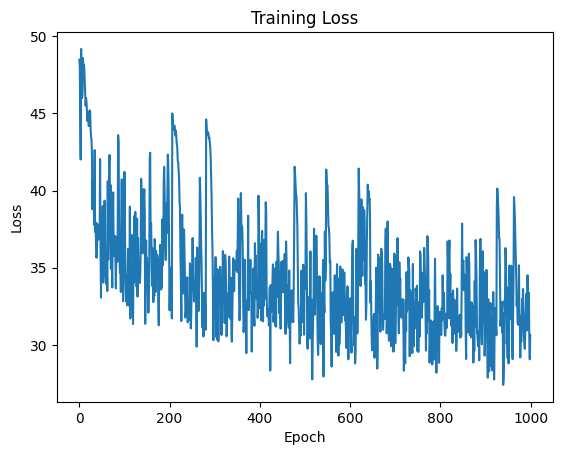

In [9]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

After training the original model, we can see it is not optimal. We can use cross validation to try and find the best hyperparameters to try and improve the model.

- https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/


In [10]:
# Lists of parameters to try
learning_rate_list = [0.01, 0.1]
weight_decay_list = [0.0, 0.01, 0.1]

"""
I had to build a cross validation function that would help try and find the best hyperparameters for the model. The
reason for the function is because we need to run the code multiple times when searching for the best parameters
and it simplifies the code.
"""
svm_classifier = SVC(C=1, kernel='rbf')

def cross_validate(X, y, num_folds=5):
    scores = []

    for train, val in KFold(n_splits=num_folds, shuffle=True, random_state=42).split(X):
        svm_classifier.fit(X[train], y[train])
        scores.append(svm_classifier.score(X[val], y[val]))

    return np.mean(scores), np.std(scores)

"""
Now we can use the cross validation function to find the optimal parameters for the model.
"""
optimal = [0, 0, 0]

for learn_rate in learning_rate_list:
    for weight_decay in weight_decay_list:

        cross_val_mean, _ = cross_validate(X_train, y_train, 5)

        if cross_val_mean > optimal[0]:
            optimal[0] = cross_val_mean
            optimal[1] = learn_rate
            optimal[2] = weight_decay

print(f"Optimal Values:\nLearn Rate={optimal[1]}\nWeight Decay={optimal[2]}")


Optimal Values:
Learn Rate=0.01
Weight Decay=0.0


# Model Evaluation

This section provides comprehensive evaluation of the logistic regression models using multiple metrics and visualizations.


- https://stackoverflow.com/questions/58002836/pytorch-1-if-x-0-5-else-0-for-x-in-outputs-with-tensors
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

In [11]:
with torch.no_grad():
    y_pred = (model(X_test_tens)> 0.5).float().squeeze().numpy()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.4f}\nRecall: {recall:.4f}\nF1 Score: {f1:.4f}")


Precision: 0.6983
Recall: 0.7089
F1 Score: 0.7036


### Confusion Matrix
This is the confusion matrix of the values after the hyperparameters were tuned. We can see that the accuracy is not the best. We have 1473 out of 2233 predictions that were correct. This gives us around 66% accuracy.

Text(50.722222222222214, 0.5, 'Actual')

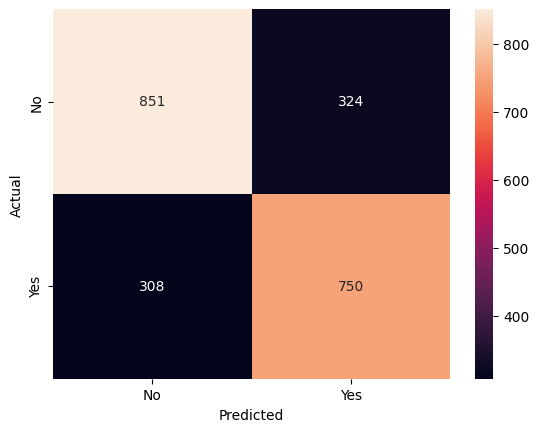

In [12]:
confusion = confusion_matrix(y_test, y_pred)

sns.heatmap(confusion, annot=True, fmt='d', 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Roc Curve

I tried implementing a roc curve but the plot seems off.

- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html

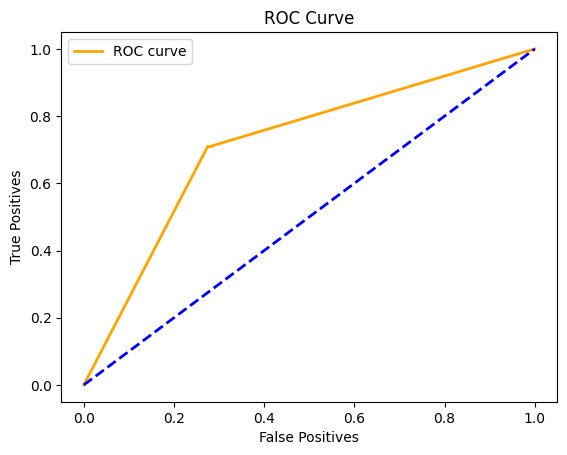

In [13]:
# ROC Curve
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tens).squeeze().numpy()

false_rate, true_rate, _ = roc_curve(y_test, y_pred)
roc_auc = auc(false_rate, true_rate)

plt.plot(false_rate, true_rate, color='orange', lw=2, label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')

plt.xlabel('False Positives')
plt.ylabel('True Positives')
plt.title('ROC Curve')
plt.legend()


# Milestone 3

#### Final Model Performance Analysis

I am going to compare my model with a Random Forest model directly from sk-learn.

PermutationExplainer explainer: 101it [00:14,  2.28it/s]                         
/var/folders/n1/xhlx0mrn5t37q8mzxp5z3_vr0000gn/T/ipykernel_4281/4140071735.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(lr_shap, data, features, max_display=10, show=False)
/var/folders/n1/xhlx0mrn5t37q8mzxp5z3_vr0000gn/T/ipykernel_4281/4140071735.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_shap, data, features, max_display=10, show=False)


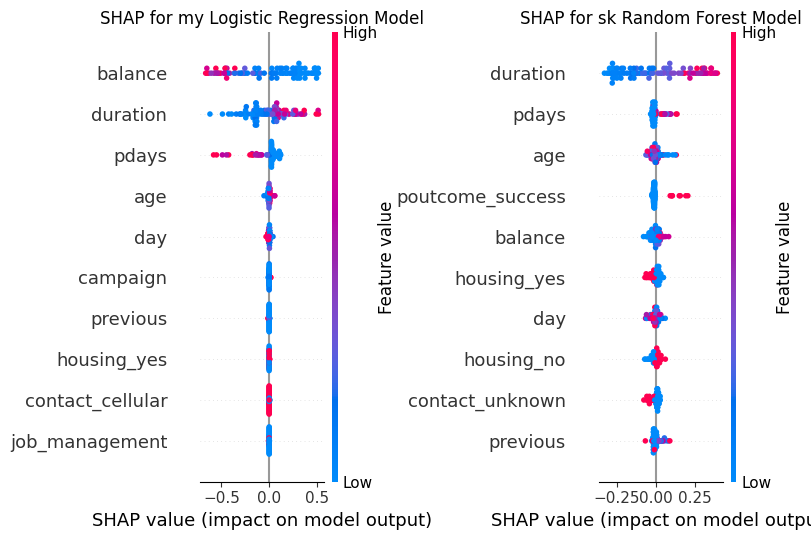

In [93]:
my_model = LogisticRegModel(X_train.shape[1])
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

my_model.eval()

random_forest.fit(X_train, y_train)

def shap_predict(x):
    x_tens = torch.FloatTensor(x)
    with torch.no_grad():
        return my_model(torch.FloatTensor(x)).numpy().flatten()

def rf_predict(x):
    return random_forest.predict_proba(x)[:, 1]

sample = np.random.choice(len(X_train), 100, replace=False)
data = X_train[sample]

lr_shap = (shap.Explainer(shap_predict, data)).shap_values(data)
rf_shap = (shap.Explainer(rf_predict, data)).shap_values(data)

features = df.columns.drop(['deposit_yes', 'deposit_no'])

fig, axs = plt.subplots(1, 2)
plt.sca(axs[0])
axs[0].set_title("SHAP for my Logistic Regression Model")
shap.summary_plot(lr_shap, data, features, max_display=10, show=False)

plt.sca(axs[1])
axs[1].set_title("SHAP for sk Random Forest Model")
shap.summary_plot(rf_shap, data, features, max_display=10, show=False)


We can see by looking at the 2 different shap plots that both my model and the random forest show that duration, balance and pdays have high impact on the output of the model. The logistic regression features get centered around zero becuase some of these features are not linear but you can see that the random forest is able to pick up on the non linear features well.

In order to improve my model we could do some feature engineering and do scaling for numeric values. We can also see that the random forest has different features that it considers more important than others so we can try to adjust this regression model to try and detect these features as well.


#### Deployment Plan
- Model:
    - Logistic Regression Model
- Data Pipelines:
    - Data Prep: Clean the data and transform it if needed
    - Warehouse: Store the data in a warehouse like Snowflake
    - Deployment: In a container like Docker
- Monitoring Systems:
    - System Monitoring
    - Model Monitoring via logs saved to cloud (AWS, etc...)
- User Interfaces:
    - Make an API for the model for development purposes
    - Make a dashboard for all of the monitoring systems and docs

#### Mock Deployment
```python
#Making the API
import fastapi
import uvicorn

app = FastAPI(title, version)

@app.get("/")
def home():
    return status message

@app.post("predict")
def predict(features):
    prediction = model.predict(list(features.values))
    return prediction

#API with docker
"""
Build the docker image with docker build -t model

Either:
Run the image locally with docker run -p port:port model

or

On the cloud through AWS EC2 with 
docker pull model
docker run -d -p port:port model

Curl the prediction reuest that has the same format as status message
"""
```

#### Scalability, Maintenance, and Compliance
I chose to use docker because we are able to add more containers if we ever run into a situation where we need more scale. We could also implement these into a kubernetes cluster to get load balancing. Maintenance can be done training the model with more data as it gets used, and making sure everything works and we are as free from bias as possible. To comply with legal regulations, we will not store personal data in plain text. If personal information needs to be stored it will need to be enctypted

#### Ethical Considerations
There are numerous considerations to take into account when working with AI/ML, those being Biases, Transparency, Privacy and how the model impacts people everyday lives. In my data set there are no biases that I was able to find but considering the basis of the data, the model has potential to make predictions that people that have a lower bank balance would not make a deposit. This is not a prediction that would directly affect the user but it could affect the stakeholders since they are being presented with data that is showing that this person from this environment is less likely to make a deposit than someone that has a high balance. It is important to communicate with users and even the stakeholders how the model makes it predictions so that if a model is making a lot of bad decisions, we can find out why. Again like mentioned above, users personal information should not be saved because it puts the users data at risk of a data breach, which we have been seeing more of lately. It is important for the model to make accurate unbiased predictions to not leave certain groups in the dark. The best way to prevent biases from taking over are to have a human audit the system every once in a while to try and detect biases and keep things fair. To keep accountability we need to keep logs of the models decisions and allow users to be able to challenge a decision that the model made if they feel like they are being unfairly targeted. We need to stay within compliance with regulations like data protection and users rights which can be done with encryption and not storing users data in a database, though this raises another question with breaking encryption. This has happened in the past when hackers were able to reverse the anonymization process of users data and figure out who they were, so it is important to review and see if we really need that type of data to begin with.